In [1]:
# Setup
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from mne.stats import fdr_correction

from eeg_toolkit import load_config
from eeg_toolkit.mvpa import load_all_scores
from eeg_toolkit.mvpa_stats import test_real_vs_null

cfg = load_config('../../configs/eye_eeg_simul.yaml')

group = load_all_scores(cfg, "cue", "spatial_vs_symbolic")
group_tg = load_all_scores(cfg, "cue", "spatial_vs_symbolic_tg64")

print("Setup OK")

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, scores shape: (30, 462)
  null scores: (30, 1, 462)
  distances: (30, 2, 462)
[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, scores shape: (30, 231)
  temporal gen: (30, 231, 231)
Setup OK


Test: real vs null
  30 subjects, threshold t=2.05, 10000 permutations
  Mean real: 0.5095, mean null: 0.4971
  Found 33 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
    permutation 8000/10000
    permutation 10000/10000

  Null distribution: mean=13.156, std=7.542, 95th=26.665, 99th=40.897
  5/33 significant clusters:
    Cluster 1: 0.230s – 0.305s, mass=55.42, p=0.0032
    Cluster 2: 0.348s – 0.426s, mass=60.59, p=0.0020
    Cluster 3: 0.461s – 0.500s, mass=37.24, p=0.0154
    Cluster 4: 0.633s – 0.676s, mass=43.18, p=0.0083
    Cluster 5: 0.715s – 0.793s, mass=70.64, p=0.0007



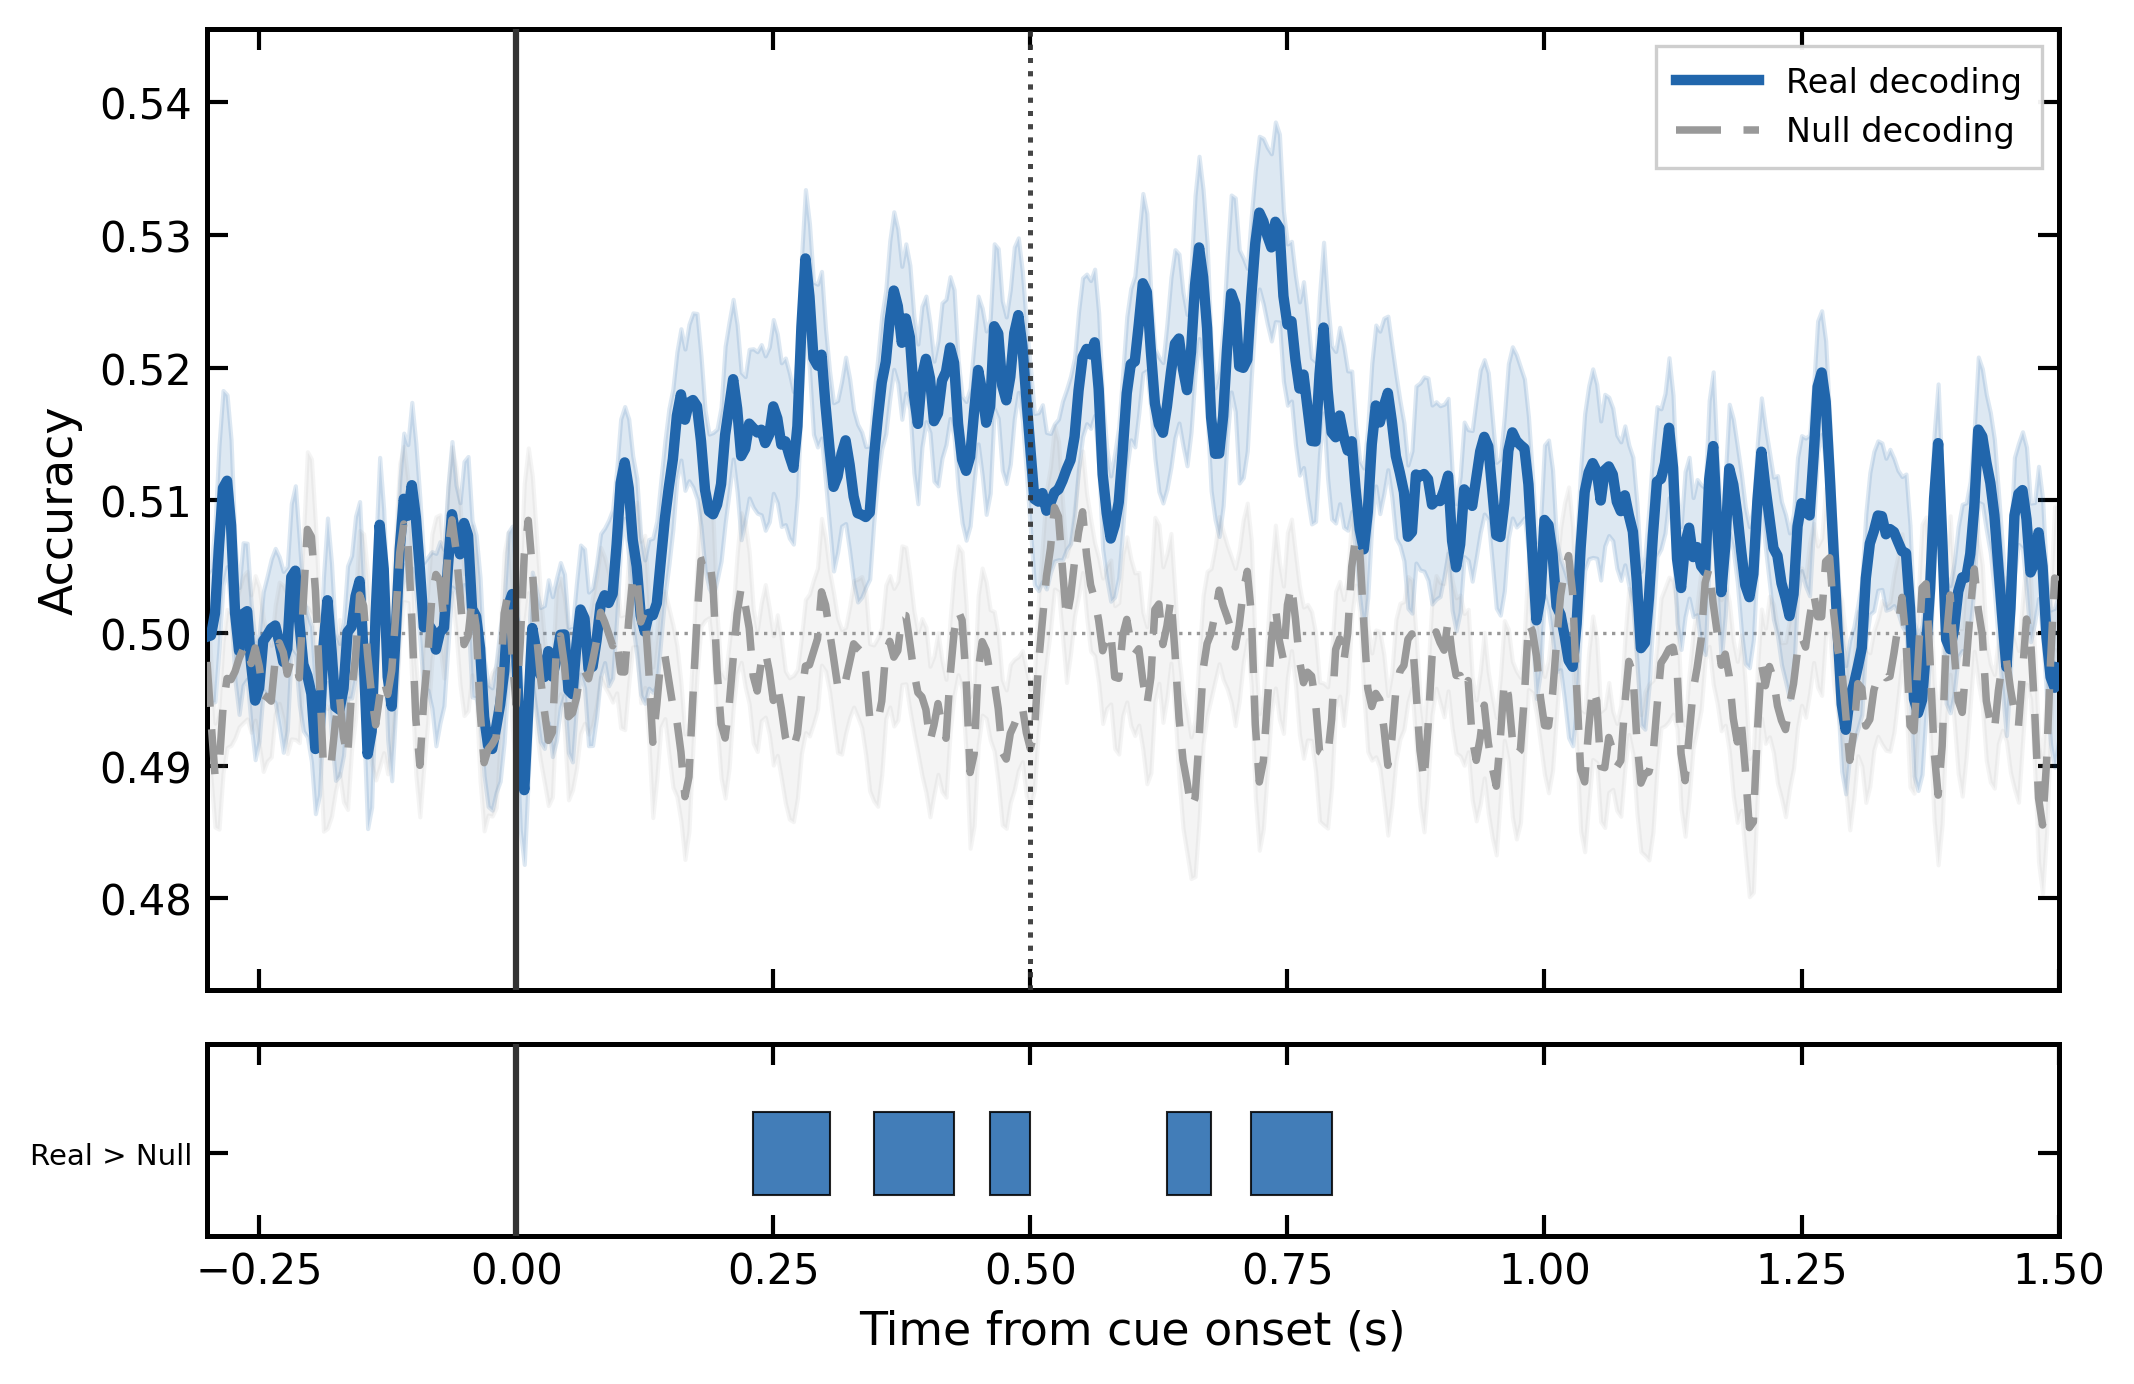


Saved to: C:\Users\juapa\OneDrive\Documentos\Proyecto doctorado\Experimentos_proyecto_tesis\Experimentos Eye Tracker\analisis\analisis_eeg\group_results\figures


In [5]:
import matplotlib.gridspec as gridspec
from pathlib import Path
from eeg_toolkit.io import get_analysis_dir

# Save path
fig_dir = get_analysis_dir(cfg) / "group_results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# ── Run cluster test ──
results_null = test_real_vs_null(group, n_permutations=10000)

# ── Extract data ──
times = group["times"]
scores = group["subject_scores"]
null = group["subject_null_scores"]
n_subj = scores.shape[0]

mean_acc = scores.mean(axis=0)
sem_acc = scores.std(axis=0) / np.sqrt(n_subj)

null_mean_per_subj = null.mean(axis=1)
mean_null = null_mean_per_subj.mean(axis=0)
sem_null = null_mean_per_subj.std(axis=0) / np.sqrt(n_subj)

sig_clusters = results_null.get("significant_clusters", [])

# ═══════════════════════════════════════════════════════════════════
# PUBLICATION FIGURE
# ═══════════════════════════════════════════════════════════════════

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

COL_REAL = '#2166AC'
COL_NULL = '#999999'

fig = plt.figure(figsize=(7, 4.5), layout='constrained')
gs = gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.08, figure=fig)

# ── Main plot ──
ax = fig.add_subplot(gs[0])

ax.plot(times, mean_acc, color=COL_REAL, lw=2.5, label="Real decoding", zorder=3)
ax.fill_between(times, mean_acc - sem_acc, mean_acc + sem_acc,
                color=COL_REAL, alpha=0.15, zorder=2)

ax.plot(times, mean_null, color=COL_NULL, lw=1.8, ls="--", label="Null decoding",
        dashes=(6, 3), zorder=3)
ax.fill_between(times, mean_null - sem_null, mean_null + sem_null,
                color=COL_NULL, alpha=0.1, zorder=2)

ax.axhline(0.5, color="#333333", lw=0.8, ls=":", alpha=0.5, zorder=1)
ax.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
ax.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)  # cue offset
ax.set_ylabel("Accuracy")
ax.set_xlim(times[0], times[-1])

all_vals = np.concatenate([mean_acc + sem_acc, mean_acc - sem_acc,
                           mean_null + sem_null, mean_null - sem_null])
y_pad = (all_vals.max() - all_vals.min()) * 0.12
ax.set_ylim(all_vals.min() - y_pad, all_vals.max() + y_pad)

plt.setp(ax.get_xticklabels(), visible=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
ax.tick_params(direction='in', top=True, right=True)

legend = ax.legend(loc='upper right', frameon=True, framealpha=0.95,
                   edgecolor='#cccccc', fancybox=False,
                   borderpad=0.6, handlelength=2.5)
legend.get_frame().set_linewidth(0.8)

# ── Significance bars ──
ax_sig = fig.add_subplot(gs[1], sharex=ax)

bar_height = 0.6
y_pos = 0

for cluster in sig_clusters:
    t_start = times[cluster["start_idx"]]
    t_end = times[cluster["end_idx"]]
    ax_sig.barh(y_pos, t_end - t_start, left=t_start, height=bar_height,
                color=COL_REAL, alpha=0.85, edgecolor='black', linewidth=0.5)

ax_sig.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
ax.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)  # cue offset

ax_sig.set_yticks([0])
ax_sig.set_yticklabels(['Real > Null'], fontsize=7)
ax_sig.set_ylim(-0.6, 0.8)
ax_sig.set_xlabel("Time from cue onset (s)")
ax_sig.set_xlim(times[0], times[-1])

for spine in ax_sig.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
ax_sig.tick_params(direction='in', top=True, right=True)

# Save
fig.savefig(fig_dir / "mvpa_decoding_spatial_vs_symbolic.png",
            dpi=600, bbox_inches='tight')
fig.savefig(fig_dir / "mvpa_decoding_spatial_vs_symbolic.tiff",
            dpi=600, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {fig_dir}")

FDR significant: 0/53361 time-time points (0.0%)


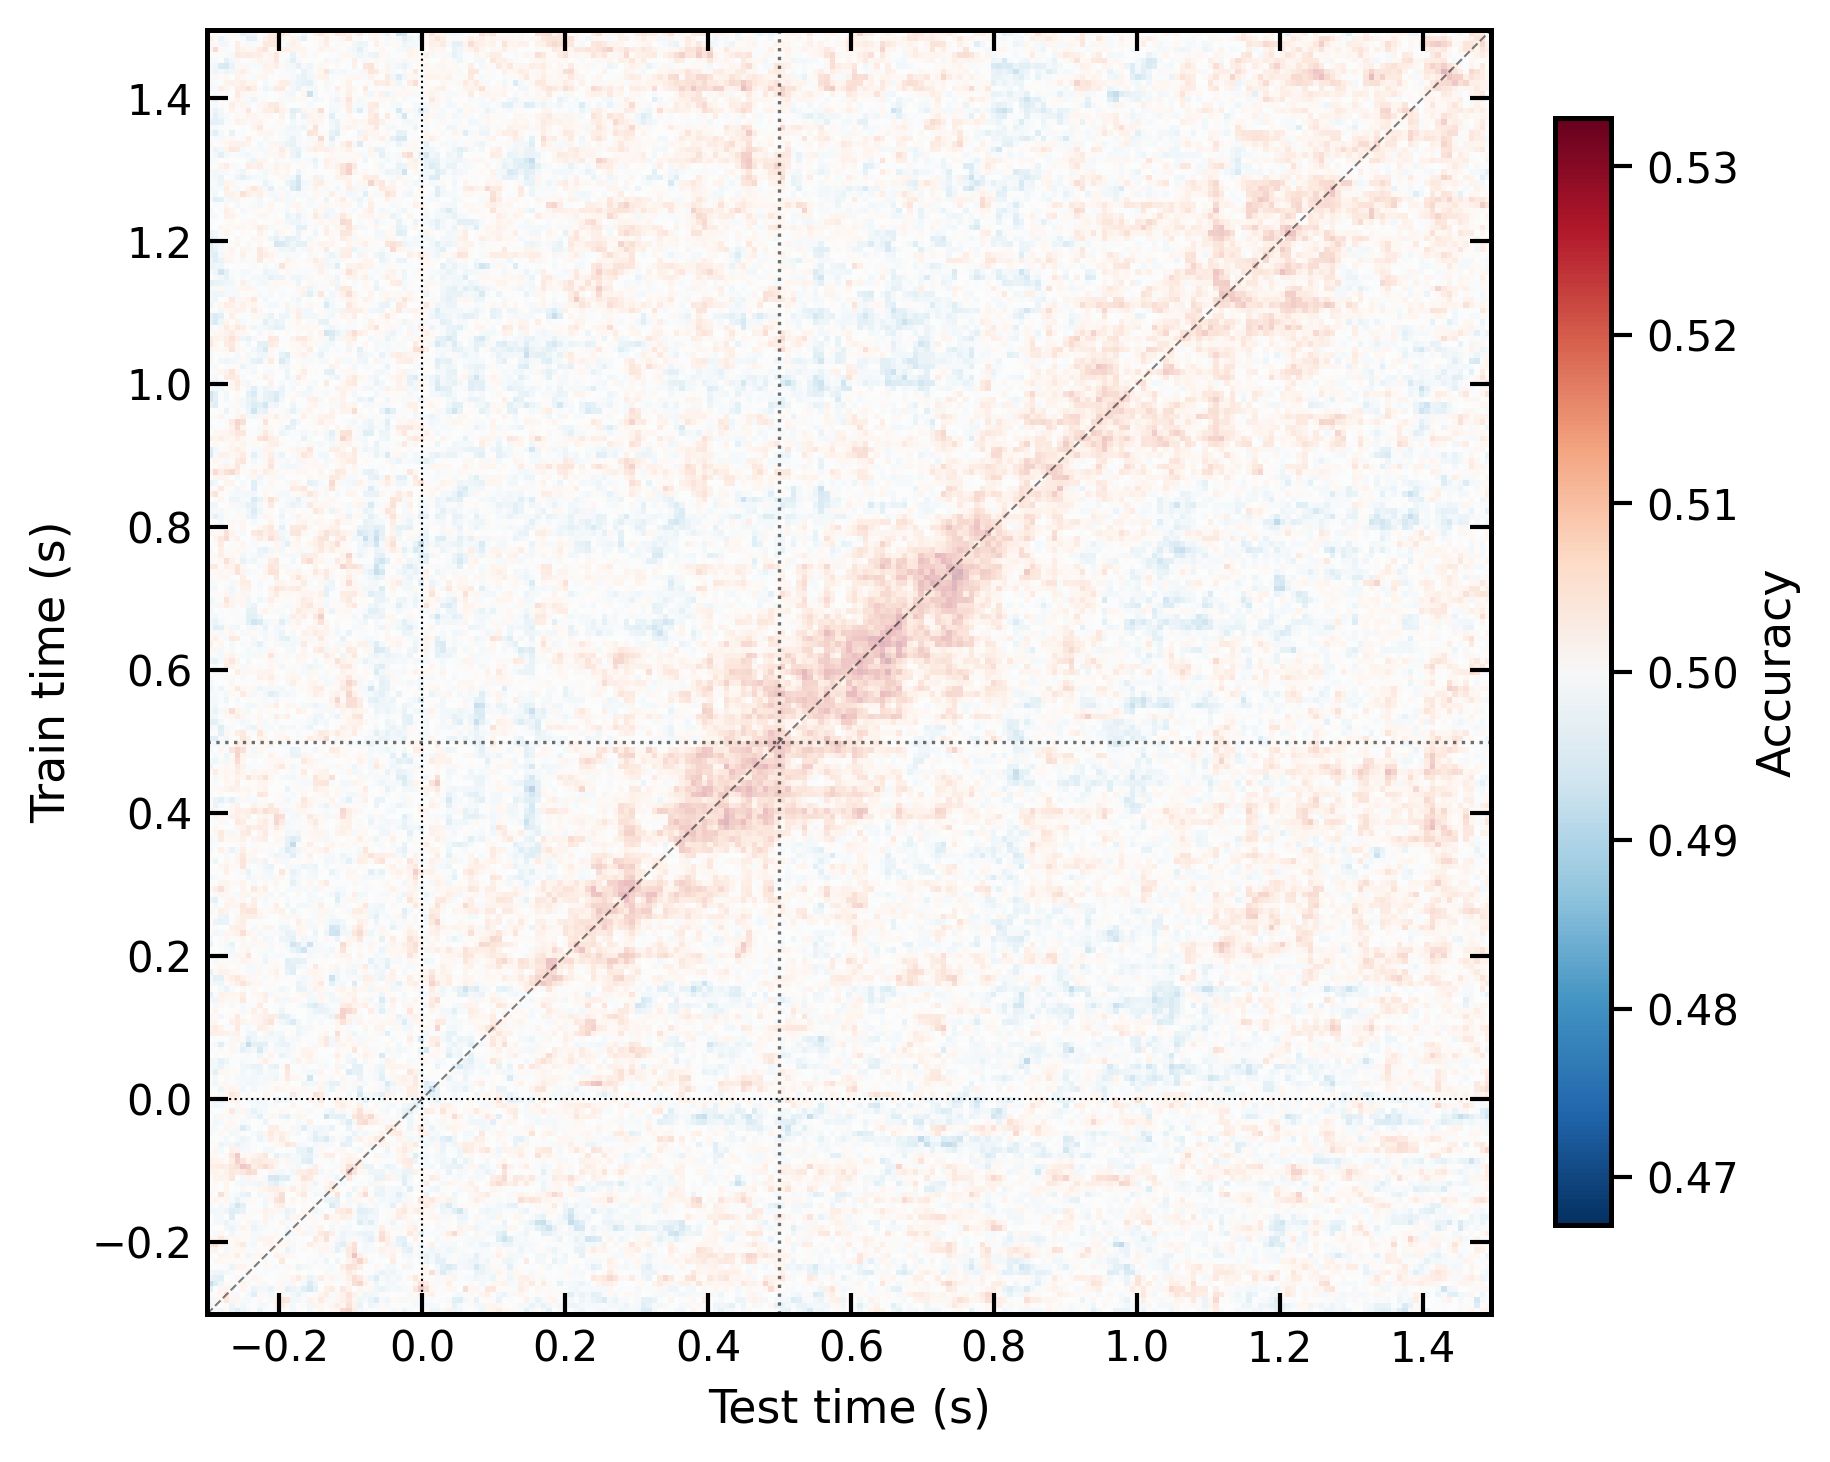

In [6]:
from scipy.stats import ttest_1samp
from mne.stats import fdr_correction

# ── Data ──
tg = group_tg["subject_temporal_gen"]    # (n_subjects, n_times, n_times)
times_tg = group_tg["times"]
n_subj = tg.shape[0]
mean_tg = tg.mean(axis=0)

# ── FDR-corrected t-test against chance at each time-time point ──
t_vals, p_vals = ttest_1samp(tg, 0.5, axis=0)
reject, p_corrected = fdr_correction(p_vals, alpha=0.05)

# ── Symmetric color limits around 0.5 ──
vmax_dev = max(abs(mean_tg.max() - 0.5), abs(mean_tg.min() - 0.5))
vmin, vmax = 0.5 - vmax_dev, 0.5 + vmax_dev

extent = [times_tg[0], times_tg[-1], times_tg[0], times_tg[-1]]

# ── Plot ──
fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')

# Full matrix at low alpha
ax.imshow(mean_tg, origin="lower", extent=extent,
          cmap="RdBu_r", vmin=vmin, vmax=vmax,
          aspect="equal", alpha=0.3)

# Significant points at full alpha
mean_tg_masked = np.ma.masked_where(~reject, mean_tg)
im = ax.imshow(mean_tg_masked, origin="lower", extent=extent,
               cmap="RdBu_r", vmin=vmin, vmax=vmax,
               aspect="equal", alpha=1.0)

ax.axhline(0, color="k", lw=0.5, ls=":")
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0.5, color="#333333", lw=0.8, ls=":", alpha=0.7)
ax.axvline(0.5, color="#333333", lw=0.8, ls=":", alpha=0.7)
ax.plot([times_tg[0], times_tg[-1]], [times_tg[0], times_tg[-1]],
        color="k", lw=0.5, ls="--", alpha=0.5)

ax.set_xlabel("Test time (s)")
ax.set_ylabel("Train time (s)")
ax.set_xlim(times_tg[0], times_tg[-1])
ax.set_ylim(times_tg[0], times_tg[-1])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
ax.tick_params(direction='in', top=True, right=True)

fig.colorbar(im, ax=ax, label="Accuracy", shrink=0.8)

n_sig = reject.sum()
n_total = reject.size
print(f"FDR significant: {n_sig}/{n_total} time-time points "
      f"({100*n_sig/n_total:.1f}%)")

# Save
fig.savefig(fig_dir / "mvpa_temporal_generalization.png",
            dpi=600, bbox_inches='tight')
fig.savefig(fig_dir / "mvpa_temporal_generalization.tiff",
            dpi=600, bbox_inches='tight')
plt.show()

In [5]:
from eeg_toolkit.mvpa_stats import test_real_vs_null, compare_analyses

# ── Load all four analyses ──
g_pos_tgt = load_all_scores(cfg, "cue", "position_spatial")
g_pos_dst = load_all_scores(cfg, "cue", "position_symbolic")
g_dig_tgt = load_all_scores(cfg, "cue", "digit_symbolic")
g_dig_dst = load_all_scores(cfg, "cue", "digit_spatial")

# ── Run stats ──
print("Position (target) vs null:")
res_pos_tgt = test_real_vs_null(g_pos_tgt, n_permutations=10000)

print("Position (distractor) vs null:")
res_pos_dst = test_real_vs_null(g_pos_dst, n_permutations=10000)

print("Digit (target) vs null:")
res_dig_tgt = test_real_vs_null(g_dig_tgt, n_permutations=10000)

print("Digit (distractor) vs null:")
res_dig_dst = test_real_vs_null(g_dig_dst, n_permutations=10000)

print("Position: target vs distractor:")
res_pos_comp = compare_analyses(g_pos_tgt, g_pos_dst, n_permutations=10000)

print("Digit: target vs distractor:")
res_dig_comp = compare_analyses(g_dig_tgt, g_dig_dst, n_permutations=10000)

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, scores shape: (30, 462)
  null scores: (30, 1, 462)
[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, scores shape: (30, 462)
  null scores: (30, 1, 462)
[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, scores shape: (30, 462)
  null scores: (30, 1, 462)
[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, scores shape: (30, 462)
  null scores: (30, 1, 462)
Position (target) vs null:
Test: real vs null
  30 subjects, threshold t=2.05, 10000 permutations
  Mean real: 0.5259, mean null: 0.4969
  Found 13 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 

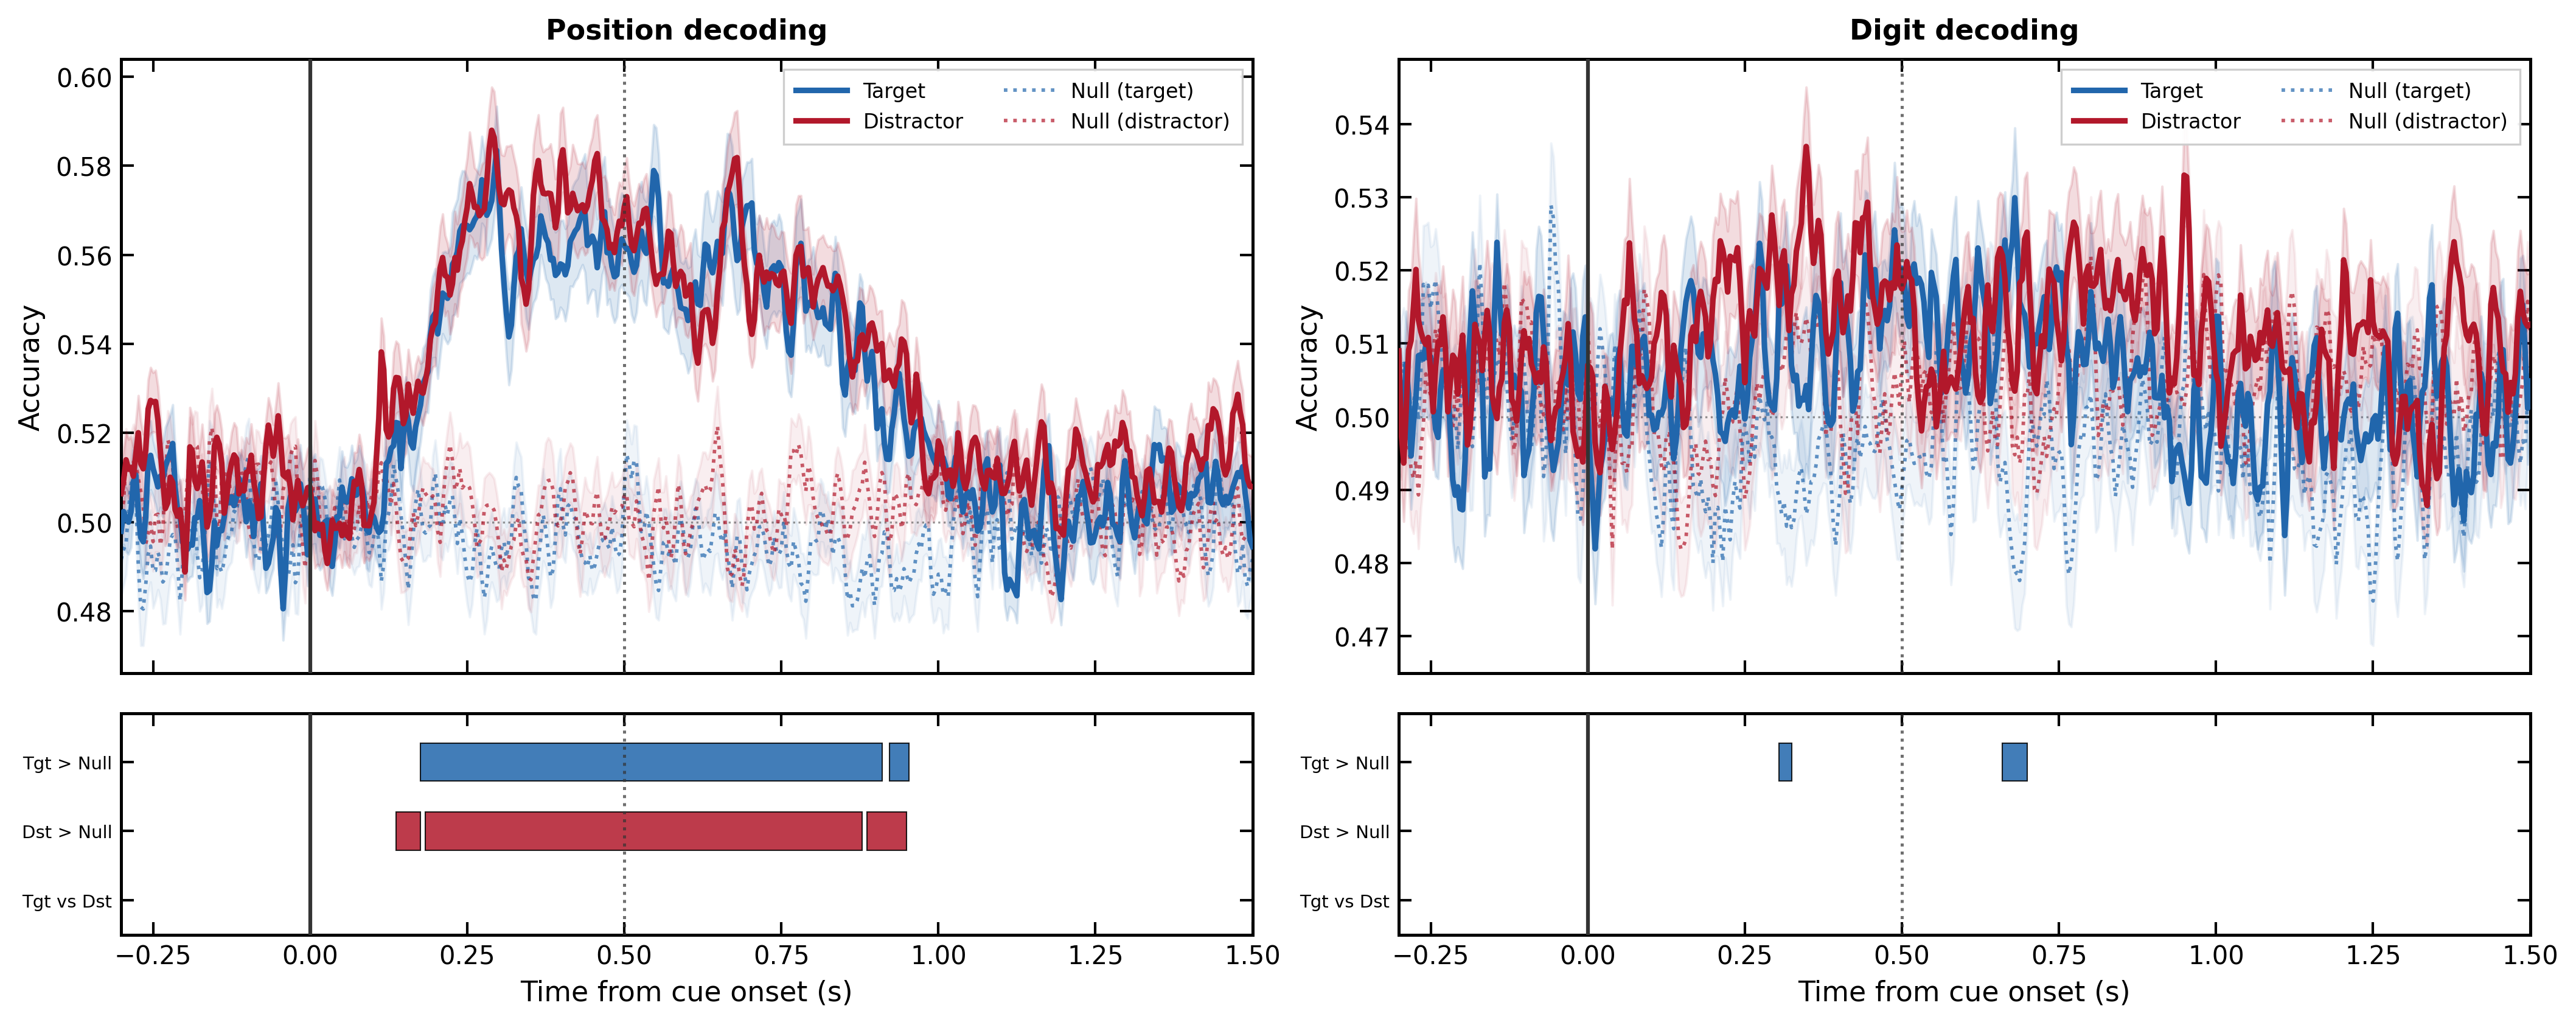


Saved to: C:\Users\juapa\OneDrive\Documentos\Proyecto doctorado\Experimentos_proyecto_tesis\Experimentos Eye Tracker\analisis\analisis_eeg\group_results\figures


In [6]:
import matplotlib.gridspec as gridspec
from eeg_toolkit.io import get_analysis_dir

fig_dir = get_analysis_dir(cfg) / "group_results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

COL_TGT = '#2166AC'
COL_DST = '#B2182B'

n_subj = g_pos_tgt["subject_scores"].shape[0]

def get_traces(group):
    s = group["subject_scores"]
    m = s.mean(axis=0)
    sem = s.std(axis=0) / np.sqrt(s.shape[0])
    return m, sem

def get_null_traces(group):
    null = group["subject_null_scores"]
    null_per_subj = null.mean(axis=1)
    m = null_per_subj.mean(axis=0)
    sem = null_per_subj.std(axis=0) / np.sqrt(null_per_subj.shape[0])
    return m, sem

def draw_sig_bars(ax, clusters, y_pos, color):
    for cl in clusters:
        t0 = times[cl["start_idx"]]
        t1 = times[cl["end_idx"]]
        ax.barh(y_pos, t1 - t0, left=t0, height=0.55,
                color=color, alpha=0.85, edgecolor='black', linewidth=0.5)

# ── Figure ──
fig = plt.figure(figsize=(14, 5.5), layout='constrained')

outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.25)

panels = [
    ("Position decoding", g_pos_tgt, g_pos_dst,
     res_pos_tgt, res_pos_dst, res_pos_comp),
    ("Digit decoding", g_dig_tgt, g_dig_dst,
     res_dig_tgt, res_dig_dst, res_dig_comp),
]

for col, (title, g_tgt, g_dst, res_tgt, res_dst, res_comp) in enumerate(panels):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[col],
                                             height_ratios=[5, 1.8], hspace=0.08)

    times = g_tgt["times"]
    m_tgt, sem_tgt = get_traces(g_tgt)
    m_dst, sem_dst = get_traces(g_dst)
    m_null_tgt, sem_null_tgt = get_null_traces(g_tgt)
    m_null_dst, sem_null_dst = get_null_traces(g_dst)

    # ── Main plot ──
    ax = fig.add_subplot(inner[0])

    # Real traces (solid)
    ax.plot(times, m_tgt, color=COL_TGT, lw=2.2, label="Target", zorder=3)
    ax.fill_between(times, m_tgt - sem_tgt, m_tgt + sem_tgt,
                    color=COL_TGT, alpha=0.15, zorder=2)

    ax.plot(times, m_dst, color=COL_DST, lw=2.2, label="Distractor", zorder=3)
    ax.fill_between(times, m_dst - sem_dst, m_dst + sem_dst,
                    color=COL_DST, alpha=0.15, zorder=2)

    # Null traces (dotted, same colors)
    ax.plot(times, m_null_tgt, color=COL_TGT, lw=1.4, ls=":",
            label="Null (target)", alpha=0.7, zorder=2)
    ax.fill_between(times, m_null_tgt - sem_null_tgt, m_null_tgt + sem_null_tgt,
                    color=COL_TGT, alpha=0.07, zorder=1)

    ax.plot(times, m_null_dst, color=COL_DST, lw=1.4, ls=":",
            label="Null (distractor)", alpha=0.7, zorder=2)
    ax.fill_between(times, m_null_dst - sem_null_dst, m_null_dst + sem_null_dst,
                    color=COL_DST, alpha=0.07, zorder=1)

    ax.axhline(0.5, color="#333333", lw=0.8, ls=":", alpha=0.5, zorder=1)
    ax.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
    ax.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)

    ax.set_xlim(times[0], times[-1])
    ax.set_ylabel("Accuracy")
    plt.setp(ax.get_xticklabels(), visible=False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    ax.tick_params(direction='in', top=True, right=True)

    legend = ax.legend(loc='upper right', frameon=True, framealpha=0.95,
                       edgecolor='#cccccc', fancybox=False,
                       borderpad=0.6, handlelength=2.5, ncol=2)
    legend.get_frame().set_linewidth(0.8)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    # ── Significance bars ──
    ax_sig = fig.add_subplot(inner[1], sharex=ax)

    sig_tgt = res_tgt.get("significant_clusters", [])
    sig_dst = res_dst.get("significant_clusters", [])
    sig_comp = res_comp.get("significant_clusters", [])

    draw_sig_bars(ax_sig, sig_tgt,  2, COL_TGT)
    draw_sig_bars(ax_sig, sig_dst,  1, COL_DST)
    draw_sig_bars(ax_sig, sig_comp, 0, '#555555')

    ax_sig.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
    ax_sig.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)

    ax_sig.set_yticks([0, 1, 2])
    ax_sig.set_yticklabels(['Tgt vs Dst', 'Dst > Null', 'Tgt > Null'], fontsize=7)
    ax_sig.set_ylim(-0.5, 2.7)
    ax_sig.set_xlabel("Time from cue onset (s)")
    ax_sig.set_xlim(times[0], times[-1])

    for spine in ax_sig.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    ax_sig.tick_params(direction='in', top=True, right=True)

fig.savefig(fig_dir / "mvpa_2x2_position_digit.png", dpi=600, bbox_inches='tight')
fig.savefig(fig_dir / "mvpa_2x2_position_digit.tiff", dpi=600, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {fig_dir}")

In [2]:
from eeg_toolkit.mvpa import load_all_cross_scores

group_xdec = load_all_cross_scores(cfg, "cue", "position_cross")

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, scores shape: (30, 462)
  null scores: (30, 1, 462)


In [3]:
results_xdec = test_real_vs_null(group_xdec, n_permutations=10000)

Test: real vs null
  30 subjects, threshold t=2.05, 10000 permutations
  Mean real: 0.5277, mean null: 0.5004
  Found 13 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
    permutation 8000/10000
    permutation 10000/10000

  Null distribution: mean=11.748, std=13.151, 95th=25.961, 99th=63.513
  2/13 significant clusters:
    Cluster 1: 0.156s – 0.809s, mass=896.20, p=0.0000
    Cluster 2: 0.816s – 0.887s, mass=65.90, p=0.0090



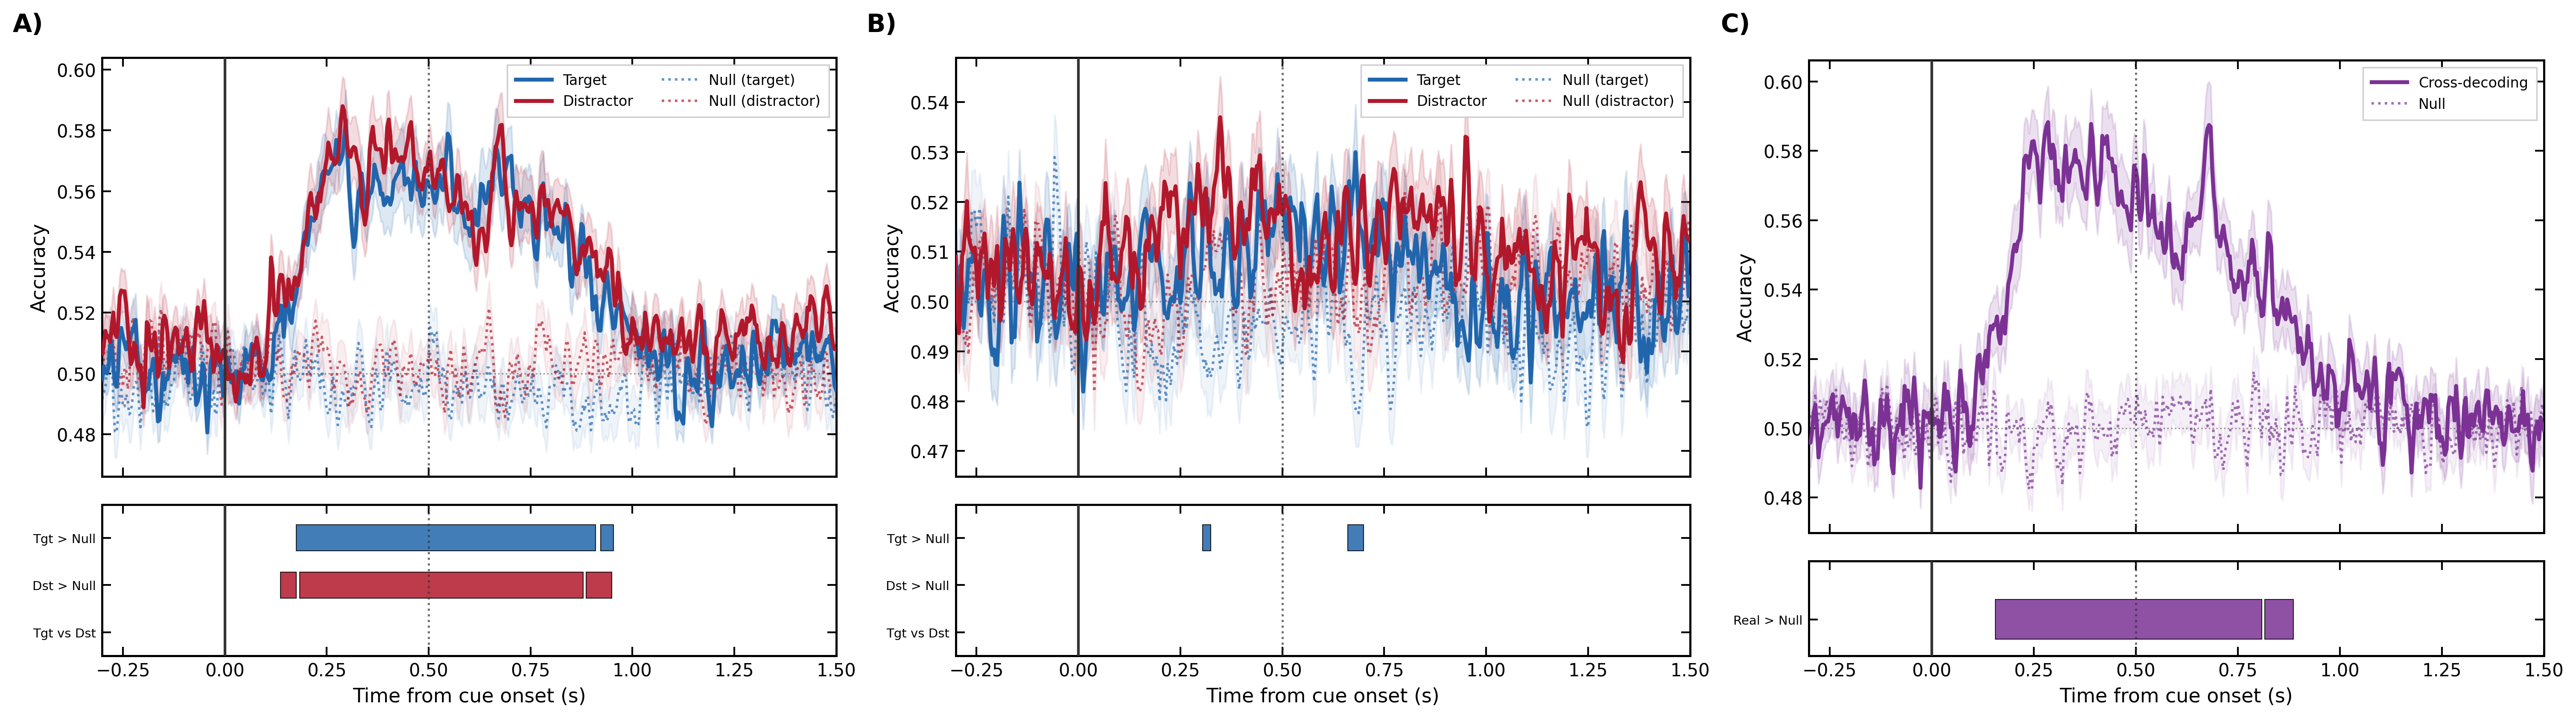


Saved to: C:\Users\juapa\OneDrive\Documentos\Proyecto doctorado\Experimentos_proyecto_tesis\Experimentos Eye Tracker\analisis\analisis_eeg\group_results\figures


In [10]:
import matplotlib.gridspec as gridspec
from eeg_toolkit.io import get_analysis_dir

fig_dir = get_analysis_dir(cfg) / "group_results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

COL_TGT = '#2166AC'
COL_DST = '#B2182B'
COL_XDEC = '#7B3294'

n_subj = g_pos_tgt["subject_scores"].shape[0]

def get_traces(group):
    s = group["subject_scores"]
    m = s.mean(axis=0)
    sem = s.std(axis=0) / np.sqrt(s.shape[0])
    return m, sem

def get_null_traces(group):
    null = group["subject_null_scores"]
    null_per_subj = null.mean(axis=1)
    m = null_per_subj.mean(axis=0)
    sem = null_per_subj.std(axis=0) / np.sqrt(null_per_subj.shape[0])
    return m, sem

def draw_sig_bars(ax, clusters, y_pos, color, times):
    for cl in clusters:
        t0 = times[cl["start_idx"]]
        t1 = times[cl["end_idx"]]
        ax.barh(y_pos, t1 - t0, left=t0, height=0.55,
                color=color, alpha=0.85, edgecolor='black', linewidth=0.5)

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    ax.tick_params(direction='in', top=True, right=True)

# ═══════════════════════════════════════════════════════════════
# FIGURE: 1×3 with significance bars
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 5.5), layout='constrained')
outer = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

# ── Panel A & B: Position and Digit (target + distractor overlaid) ──
panels_ab = [
    ("Position decoding", g_pos_tgt, g_pos_dst,
     res_pos_tgt, res_pos_dst, res_pos_comp),
    ("Digit decoding", g_dig_tgt, g_dig_dst,
     res_dig_tgt, res_dig_dst, res_dig_comp),
]

for col, (title, g_tgt, g_dst, res_tgt, res_dst, res_comp) in enumerate(panels_ab):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[col],
                                             height_ratios=[5, 1.8], hspace=0.08)

    times = g_tgt["times"]
    m_tgt, sem_tgt = get_traces(g_tgt)
    m_dst, sem_dst = get_traces(g_dst)
    m_null_tgt, sem_null_tgt = get_null_traces(g_tgt)
    m_null_dst, sem_null_dst = get_null_traces(g_dst)

    # Main plot
    ax = fig.add_subplot(inner[0])

    ax.plot(times, m_tgt, color=COL_TGT, lw=2.2, label="Target", zorder=3)
    ax.fill_between(times, m_tgt - sem_tgt, m_tgt + sem_tgt,
                    color=COL_TGT, alpha=0.15, zorder=2)

    ax.plot(times, m_dst, color=COL_DST, lw=2.2, label="Distractor", zorder=3)
    ax.fill_between(times, m_dst - sem_dst, m_dst + sem_dst,
                    color=COL_DST, alpha=0.15, zorder=2)

    ax.plot(times, m_null_tgt, color=COL_TGT, lw=1.4, ls=":",
            label="Null (target)", alpha=0.7, zorder=2)
    ax.fill_between(times, m_null_tgt - sem_null_tgt, m_null_tgt + sem_null_tgt,
                    color=COL_TGT, alpha=0.07, zorder=1)

    ax.plot(times, m_null_dst, color=COL_DST, lw=1.4, ls=":",
            label="Null (distractor)", alpha=0.7, zorder=2)
    ax.fill_between(times, m_null_dst - sem_null_dst, m_null_dst + sem_null_dst,
                    color=COL_DST, alpha=0.07, zorder=1)

    ax.axhline(0.5, color="#333333", lw=0.8, ls=":", alpha=0.5, zorder=1)
    ax.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
    ax.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)

    ax.set_xlim(times[0], times[-1])
    ax.set_ylabel("Accuracy")
    plt.setp(ax.get_xticklabels(), visible=False)
    style_axes(ax)

    legend = ax.legend(loc='upper right', frameon=True, framealpha=0.95,
                       edgecolor='#cccccc', fancybox=False,
                       borderpad=0.6, handlelength=2.5, ncol=2)
    legend.get_frame().set_linewidth(0.8)
    # ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    panel_label = "A)" if col == 0 else "B)"
    ax.text(-0.08, 1.05, panel_label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='bottom', ha='right')
    # Significance bars
    ax_sig = fig.add_subplot(inner[1], sharex=ax)

    draw_sig_bars(ax_sig, res_tgt.get("significant_clusters", []), 2, COL_TGT, times)
    draw_sig_bars(ax_sig, res_dst.get("significant_clusters", []), 1, COL_DST, times)
    draw_sig_bars(ax_sig, res_comp.get("significant_clusters", []), 0, '#555555', times)

    ax_sig.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
    ax_sig.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)

    ax_sig.set_yticks([0, 1, 2])
    ax_sig.set_yticklabels(['Tgt vs Dst', 'Dst > Null', 'Tgt > Null'], fontsize=7)
    ax_sig.set_ylim(-0.5, 2.7)
    ax_sig.set_xlabel("Time from cue onset (s)")
    ax_sig.set_xlim(times[0], times[-1])
    style_axes(ax_sig)

# ── Panel C: Cross-decoding ──
inner_c = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[2],
                                           height_ratios=[5, 1.0], hspace=0.08)

times_x = group_xdec["times"]
m_xdec, sem_xdec = get_traces(group_xdec)
m_null_xdec, sem_null_xdec = get_null_traces(group_xdec)

ax_c = fig.add_subplot(inner_c[0])

ax_c.plot(times_x, m_xdec, color=COL_XDEC, lw=2.2,
          label="Cross-decoding", zorder=3)
ax_c.fill_between(times_x, m_xdec - sem_xdec, m_xdec + sem_xdec,
                  color=COL_XDEC, alpha=0.15, zorder=2)

ax_c.plot(times_x, m_null_xdec, color=COL_XDEC, lw=1.4, ls=":",
          label="Null", alpha=0.7, zorder=2)
ax_c.fill_between(times_x, m_null_xdec - sem_null_xdec,
                  m_null_xdec + sem_null_xdec,
                  color=COL_XDEC, alpha=0.07, zorder=1)

ax_c.axhline(0.5, color="#333333", lw=0.8, ls=":", alpha=0.5, zorder=1)
ax_c.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
ax_c.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)

ax_c.set_xlim(times_x[0], times_x[-1])
ax_c.set_ylabel("Accuracy")
plt.setp(ax_c.get_xticklabels(), visible=False)
style_axes(ax_c)

legend_c = ax_c.legend(loc='upper right', frameon=True, framealpha=0.95,
                       edgecolor='#cccccc', fancybox=False,
                       borderpad=0.6, handlelength=2.5)
legend_c.get_frame().set_linewidth(0.8)
# ax_c.set_title("Cross-decoding (position)", fontsize=11, fontweight='bold', pad=8)
ax_c.text(-0.08, 1.05, "C)", transform=ax_c.transAxes,
          fontsize=14, fontweight='bold', va='bottom', ha='right')

# Significance bar
ax_sig_c = fig.add_subplot(inner_c[1], sharex=ax_c)

draw_sig_bars(ax_sig_c, results_xdec.get("significant_clusters", []),
              0, COL_XDEC, times_x)

ax_sig_c.axvline(0, color="#333333", lw=1.5, ls="-", zorder=4)
ax_sig_c.axvline(0.5, color="#333333", lw=1.2, ls=":", alpha=0.7, zorder=4)

ax_sig_c.set_yticks([0])
ax_sig_c.set_yticklabels(['Real > Null'], fontsize=7)
ax_sig_c.set_ylim(-0.5, 0.8)
ax_sig_c.set_xlabel("Time from cue onset (s)")
ax_sig_c.set_xlim(times_x[0], times_x[-1])
style_axes(ax_sig_c)

# ── Save ──
fig.savefig(fig_dir / "mvpa_full_panel.png", dpi=600, bbox_inches='tight')
fig.savefig(fig_dir / "mvpa_full_panel.tiff", dpi=600, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {fig_dir}")